In [3]:
import numpy as np
from sklearn.model_selection import train_test_split

In [4]:
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8, 
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7, 
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [5]:
fish_data = np.column_stack((fish_length, fish_weight))
fish_target = np.concatenate((np.ones(35), np.zeros(14)))

In [7]:
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, stratify=fish_target, random_state=42)

In [8]:
from sklearn.neighbors import KNeighborsClassifier

In [9]:
kn = KNeighborsClassifier()
kn.fit(train_input, train_target)

KNeighborsClassifier()

In [10]:
kn.score(test_input, test_target)

1.0

In [11]:
print(kn.predict([[25, 150]]))

[0.]


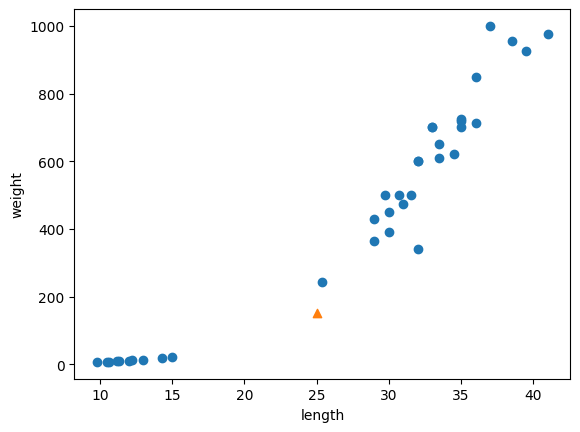

In [12]:
import matplotlib.pyplot as plt
plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(25, 150, marker="^")
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [13]:
distances, indexes = kn.kneighbors([[25, 150]])

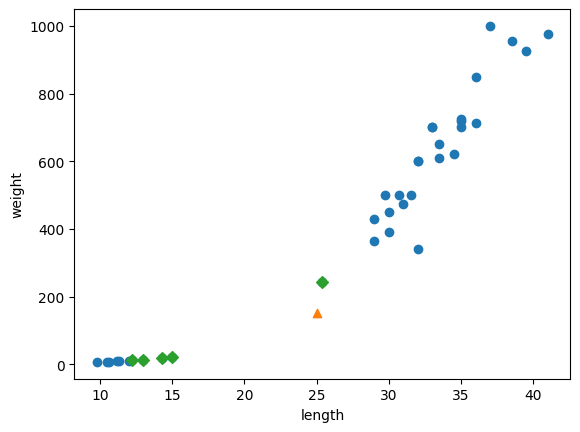

In [15]:
plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(25, 150, marker="^")
plt.scatter(train_input[indexes, 0], train_input[indexes, 1], marker="D")
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [16]:
mean = np.mean(train_input, axis=0)
std = np.std(train_input, axis=0)
print(mean, std)

[ 27.29722222 454.09722222] [  9.98244253 323.29893931]


In [17]:
train_scaled = (train_input - mean)/std

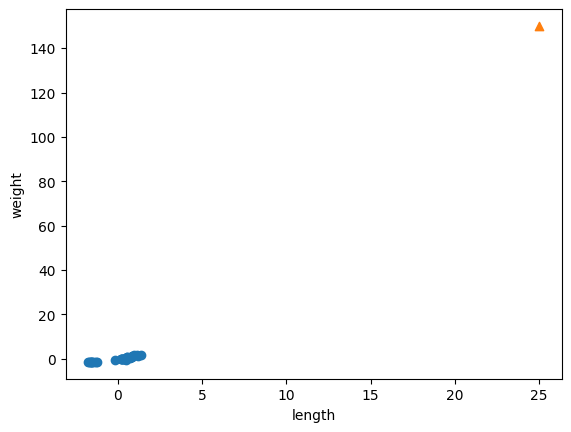

In [18]:
plt.scatter(train_scaled[:, 0], train_scaled[:, 1])
plt.scatter(25, 150, marker="^")
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

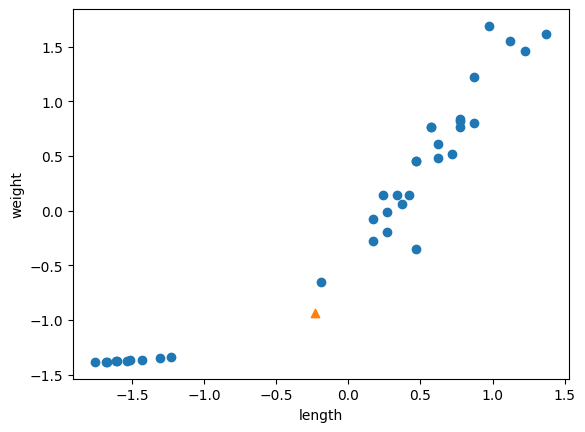

In [19]:
scaled = ([25, 150] - mean)/std
plt.scatter(train_scaled[:, 0], train_scaled[:, 1])
plt.scatter(scaled[0], scaled[1], marker="^")
plt.xlabel('length')
plt.ylabel('weight')
plt.show() 

In [20]:
kn.fit(train_scaled, train_target)

KNeighborsClassifier()

In [21]:
test_scaled = (test_input - mean)/std
kn.score(test_scaled, test_target)

1.0

In [22]:
kn.predict([scaled])

array([1.])

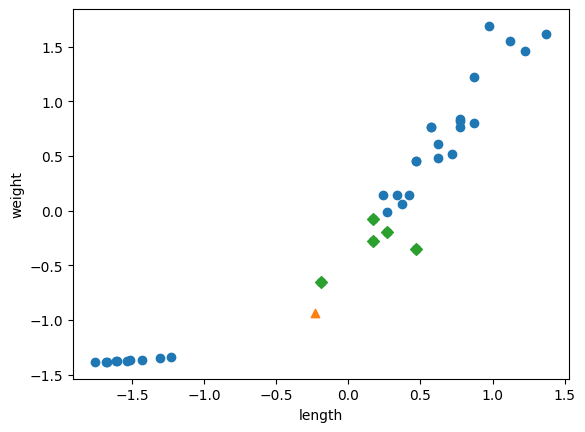

In [23]:
distances, indexes = kn.kneighbors([scaled])
plt.scatter(train_scaled[:, 0], train_scaled[:, 1])
plt.scatter(scaled[0], scaled[1], marker="^")
plt.scatter(train_scaled[indexes, 0], train_scaled[indexes, 1], marker="D")
plt.xlabel('length')
plt.ylabel('weight')
plt.show()